# Visualisasi severity

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from pathlib import Path

In [ ]:
# Untuk mendapatkan daftar file gambar dan label
image_dir = Path("../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession/train/images")
label_dir = Path("../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession/train/labels")

image_map = {p.stem: p for p in image_dir.glob("*.jpg")}
label_map = {p.stem: p for p in label_dir.glob("*.txt")}

common_keys = sorted(set(image_map) & set(label_map))[:1] # Batasi hanya pada 1 file untuk pengujian

image_paths = [str(image_map[k]) for k in common_keys]
label_paths = [str(label_map[k]) for k in common_keys]

Severity pada Daun Terbesar: 2.09%


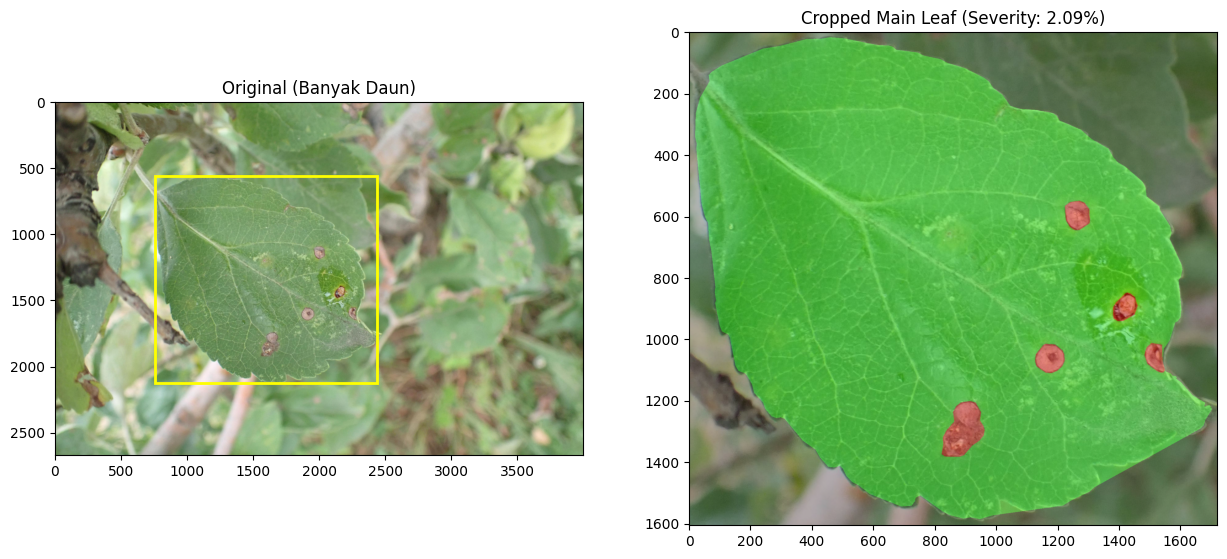

In [25]:
# Fungsi untuk visualisasi daun terbesar dan menghitung severity
def visualize_largest_leaf_severity(image_path, label_path):
    class_names = ['frog-eye-leaf-spot', 'frog-eye-leaf-spot_lession', 'healthy', 'rust', 'rust_lession']
    leaf_classes = [0, 2, 3]    # frog-eye, healthy, rust (Host/Daun)
    lesion_classes = [1, 4]     # lession classes

    img = cv2.imread(image_path)
    if img is None: return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    annotations = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                data = line.split()
                cls = int(data[0])
                pts = np.array(data[1:], dtype=np.float32).reshape(-1, 2)
                pts[:, 0] *= w
                pts[:, 1] *= h
                
                # Hitung Bounding Box (x_min, y_min, x_max, y_max)
                x_min, y_min = np.min(pts, axis=0)
                x_max, y_max = np.max(pts, axis=0)
                area_bb = (x_max - x_min) * (y_max - y_min)
                
                annotations.append({
                    'class_id': cls,
                    'points': pts.astype(np.int32),
                    'bbox': [x_min, y_min, x_max, y_max],
                    'area_bb': area_bb
                })

    if not annotations:
        print("Tidak ada anotasi ditemukan.")
        return

    # 1. Cari Daun dengan Bounding Box Terbesar
    leaf_annots = [a for a in annotations if a['class_id'] in leaf_classes]
    if not leaf_annots:
        print("Tidak ada objek daun terdeteksi.")
        return
    
    main_leaf = max(leaf_annots, key=lambda x: x['area_bb'])
    lx1, ly1, lx2, ly2 = main_leaf['bbox']

    # 2. Filter Lesi yang berada di dalam Bounding Box Daun Terbesar
    # Kita gunakan pengecekan apakah titik pusat lesi ada di dalam kotak daun
    filtered_lesions = []
    for a in annotations:
        if a['class_id'] in lesion_classes:
            # Ambil titik pusat (centroid) lesi
            cx, cy = np.mean(a['points'], axis=0)
            if lx1 <= cx <= lx2 and ly1 <= cy <= ly2:
                filtered_lesions.append(a)

    # 3. Hitung Luas & Buat Mask (Hanya untuk yang terpilih)
    semantic_mask = np.zeros_like(img_rgb)
    
    # Hitung luas daun utama
    temp_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(temp_mask, [main_leaf['points']], 1)
    leaf_area_px = np.sum(temp_mask)
    cv2.fillPoly(semantic_mask, [main_leaf['points']], [0, 255, 0]) # Hijau

    # Hitung luas lesi yang terfilter
    lesion_area_px = 0
    for l in filtered_lesions:
        l_mask = np.zeros((h, w), dtype=np.uint8)
        cv2.fillPoly(l_mask, [l['points']], 1)
        lesion_area_px += np.sum(l_mask)
        cv2.fillPoly(semantic_mask, [l['points']], [255, 0, 0]) # Merah

    # 4. Kalkulasi Severity
    severity = (lesion_area_px / leaf_area_px * 100) if leaf_area_px > 0 else 0

    # 5. Crop Gambar ke Daun Terbesar (Sesuai alur thesis Anda)
    # Tambahkan sedikit margin agar tidak terlalu mepet (padding 20px)
    pad = 20
    crop_x1, crop_y1 = max(0, int(lx1-pad)), max(0, int(ly1-pad))
    crop_x2, crop_y2 = min(w, int(lx2+pad)), min(h, int(ly2+pad))
    
    crop_img = img_rgb[crop_y1:crop_y2, crop_x1:crop_x2]
    crop_mask = semantic_mask[crop_y1:crop_y2, crop_x1:crop_x2]
    overlay_crop = cv2.addWeighted(crop_img, 0.7, crop_mask, 0.3, 0)

    # 6. Tampilkan Hasil
    print(f"Severity pada Daun Terbesar: {severity:.2f}%")
    
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))
    ax[0].imshow(img_rgb)
    ax[0].set_title("Original (Banyak Daun)")
    # Gambar kotak deteksi daun terpilih di gambar asli
    rect = plt.Rectangle((lx1, ly1), lx2-lx1, ly2-ly1, fill=False, color='yellow', linewidth=2)
    ax[0].add_patch(rect)
    
    ax[1].imshow(overlay_crop)
    ax[1].set_title(f"Cropped Main Leaf (Severity: {severity:.2f}%)")
    
    plt.show()

# Jalankan
for image_path2, label_path2 in zip(image_paths, label_paths):
    visualize_largest_leaf_severity(image_path2, label_path2)

# Pembuatan Ground Truth

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from tqdm import tqdm

def process_leaf_dataset(base_path, subsets=['train', 'test', 'valid']):
    class_names = ['frog-eye-leaf-spot', 'frog-eye-leaf-spot_lession', 'healthy', 'rust', 'rust_lession']
    leaf_classes = [0, 2, 3]
    lesion_classes = [1, 4]

    for subset in subsets:
        print(f"\nMemproses subset: {subset}...")
        
        # 1. Definisi Path
        img_dir = os.path.join(base_path, subset, 'images')
        lbl_dir = os.path.join(base_path, subset, 'labels')
        
        # Path Output
        csv_output_dir = f'results/{subset}/csv'
        plot_output_dir = f'results/{subset}/severity_estimation_plot'
        os.makedirs(csv_output_dir, exist_ok=True)
        os.makedirs(plot_output_dir, exist_ok=True)

        data_list = []
        image_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        for idx, filename in enumerate(tqdm(image_files)):
            image_path = os.path.join(img_dir, filename)
            label_path = os.path.join(lbl_dir, os.path.splitext(filename)[0] + '.txt')

            if not os.path.exists(label_path):
                continue

            # Load Gambar
            img = cv2.imread(image_path)
            if img is None: continue
            h, w, _ = img.shape
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Baca Anotasi
            annotations = []
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    data = line.split()
                    cls = int(data[0])
                    pts = np.array(data[1:], dtype=np.float32).reshape(-1, 2)
                    pts[:, 0] *= w
                    pts[:, 1] *= h
                    
                    x_min, y_min = np.min(pts, axis=0)
                    x_max, y_max = np.max(pts, axis=0)
                    area_bb = (x_max - x_min) * (y_max - y_min)
                    
                    annotations.append({
                        'class_id': cls,
                        'points': pts.astype(np.int32),
                        'bbox': [x_min, y_min, x_max, y_max],
                        'area_bb': area_bb
                    })

            # Filter Daun Terbesar
            leaf_annots = [a for a in annotations if a['class_id'] in leaf_classes]
            if not leaf_annots: continue
            
            main_leaf = max(leaf_annots, key=lambda x: x['area_bb'])
            lx1, ly1, lx2, ly2 = main_leaf['bbox']

            # Filter Lesi pada Daun Terbesar
            filtered_lesions = []
            for a in annotations:
                if a['class_id'] in lesion_classes:
                    cx, cy = np.mean(a['points'], axis=0)
                    if lx1 <= cx <= lx2 and ly1 <= cy <= ly2:
                        filtered_lesions.append(a)

            # Hitung Luas Mask
            semantic_mask = np.zeros_like(img_rgb)
            m_mask = np.zeros((h, w), dtype=np.uint8)
            cv2.fillPoly(m_mask, [main_leaf['points']], 1)
            leaf_area_px = np.sum(m_mask)
            cv2.fillPoly(semantic_mask, [main_leaf['points']], [0, 255, 0]) # Green

            lesion_area_px = 0
            for l in filtered_lesions:
                l_mask = np.zeros((h, w), dtype=np.uint8)
                cv2.fillPoly(l_mask, [l['points']], 1)
                lesion_area_px += np.sum(l_mask)
                cv2.fillPoly(semantic_mask, [l['points']], [255, 0, 0]) # Red

            severity = (lesion_area_px / leaf_area_px * 100) if leaf_area_px > 0 else 0

            # Simpan Data untuk CSV
            data_list.append({
                "no": len(data_list) + 1,
                "nama_file": filename,
                "luas_daun": leaf_area_px,
                "luas_lesi": lesion_area_px,
                "severity_estimation": f"{severity:.2f}%"
            })

            # 2. Plotting (Tanpa muncul popup)
            plt.ioff() # Matikan mode interaktif agar tidak popup
            fig, ax = plt.subplots(1, 2, figsize=(16, 8))
            
            # Gambar Asli + Box
            ax[0].imshow(img_rgb)
            ax[0].set_title(f"Original: {filename}")
            rect = plt.Rectangle((lx1, ly1), lx2-lx1, ly2-ly1, fill=False, color='yellow', linewidth=3)
            ax[0].add_patch(rect)
            ax[0].axis('off')
            
            # Crop Detail
            pad = 30
            cx1, cy1 = max(0, int(lx1-pad)), max(0, int(ly1-pad))
            cx2, cy2 = min(w, int(lx2+pad)), min(h, int(ly2+pad))
            crop_img = img_rgb[cy1:cy2, cx1:cx2]
            crop_mask = semantic_mask[cy1:cy2, cx1:cx2]
            overlay_crop = cv2.addWeighted(crop_img, 0.7, crop_mask, 0.3, 0)
            
            ax[1].imshow(overlay_crop)
            ax[1].set_title(f"Main Leaf Crop (Severity: {severity:.2f}%)")
            ax[1].axis('off')

            # Simpan Plot
            plt.savefig(os.path.join(plot_output_dir, filename), bbox_inches='tight')
            plt.close(fig) # Hapus figure dari memori

        # 3. Simpan CSV per Subset
        df = pd.DataFrame(data_list)
        csv_name = f'severity_results_{subset}.csv'
        df.to_csv(os.path.join(csv_output_dir, csv_name), index=False)
        print(f"Selesai! CSV disimpan di: {csv_output_dir}")

# Jalankan Script
BASE_DATASET_PATH = '../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession'
process_leaf_dataset(BASE_DATASET_PATH)


Memproses subset: train...


100%|██████████| 525/525 [06:22<00:00,  1.37it/s]


Selesai! CSV disimpan di: results/train/csv

Memproses subset: test...


100%|██████████| 150/150 [01:56<00:00,  1.29it/s]


Selesai! CSV disimpan di: results/test/csv

Memproses subset: valid...


100%|██████████| 75/75 [00:55<00:00,  1.34it/s]

Selesai! CSV disimpan di: results/valid/csv
